In [ ]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import shap

In [ ]:
# ---------------- CONFIG ----------------
DATA_PATH = "/content/smartloan_dataset_final.csv"
RANDOM_STATE = 42

In [ ]:
# ---------------- LOAD DATA ----------------
df = pd.read_csv(DATA_PATH)
print("✅ Dataset loaded:", df.shape)

target_col = "Eligibility_Status"
y_raw = df[target_col]
X = df.drop(columns=[target_col])


✅ Dataset loaded: (7000, 17)


In [ ]:
# ---------------- TARGET ENCODING ----------------
mapping = {"Not Eligible": 0, "Partially Eligible": 1, "Fully Eligible": 2}
y = np.array([mapping.get(v, 0) for v in y_raw])

In [ ]:
# ---------------- TRAIN/TEST SPLIT ----------------
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
for tr, te in sss.split(X, y):
    X_train, X_test = X.iloc[tr].copy(), X.iloc[te].copy()
    y_train, y_test = y[tr], y[te]
print("✅ Train/Test Split:", X_train.shape, X_test.shape)

✅ Train/Test Split: (5600, 16) (1400, 16)


In [ ]:

# ---------------- PREPROCESSING ----------------
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
preproc = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

X_train_p = preproc.fit_transform(X_train)
X_test_p = preproc.transform(X_test)

In [ ]:
# ---------------- MODELS ----------------
xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob", num_class=3,
    learning_rate=0.05, n_estimators=250, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.15, reg_lambda=0.5,
    random_state=RANDOM_STATE, n_jobs=-1, eval_metric="mlogloss"
)
rf_clf = RandomForestClassifier(
    n_estimators=250, max_depth=12, random_state=RANDOM_STATE,
    class_weight="balanced_subsample", n_jobs=-1
)
lr_clf = LogisticRegression(max_iter=1000, solver="liblinear", class_weight="balanced")

print("\n⚙️ Training models (XGBoost + RF + Logistic)...")

# Ensure all 3 classes are represented
for cls in [0, 1, 2]:
    if cls not in np.unique(y_train):
        X_train_p = np.vstack([X_train_p, X_train_p[0]])
        y_train = np.append(y_train, cls)

xgb_clf.fit(X_train_p, y_train)
rf_clf.fit(X_train_p, y_train)
lr_clf.fit(X_train_p, y_train)

voting = VotingClassifier(
    estimators=[("xgb", xgb_clf), ("rf", rf_clf), ("lr", lr_clf)],
    voting="soft", n_jobs=-1
)
voting.fit(X_train_p, y_train)


⚙️ Training models (XGBoost + RF + Logistic)...


VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='mlogloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_co...
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=250, n_jobs=-1,
                                            num_class=3, ...)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced_subsample',
                                                     max_depth=12,
                                                     n_estimators=250,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('lr',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=1000,
                                                 solver='liblinear'))],
                 n_jobs=-1, voting='soft')

In [ ]:
# ---------------- PERFORMANCE ----------------
y_pred = voting.predict(X_test_p)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Ensemble Accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred, zero_division=0))


✅ Ensemble Accuracy: 0.994
              precision    recall  f1-score   support

           1       0.91      0.83      0.87        35
           2       1.00      1.00      1.00      1365

    accuracy                           0.99      1400
   macro avg       0.95      0.91      0.93      1400
weighted avg       0.99      0.99      0.99      1400



In [ ]:
# ---------------- FEATURE SELECTION ----------------
selector = SelectFromModel(rf_clf, threshold="median", prefit=True)
X_all_p = preproc.transform(X)
X_all_sel = selector.transform(X_all_p)
approved_mask = (y == 2)
approved_matrix = X_all_sel[approved_mask]


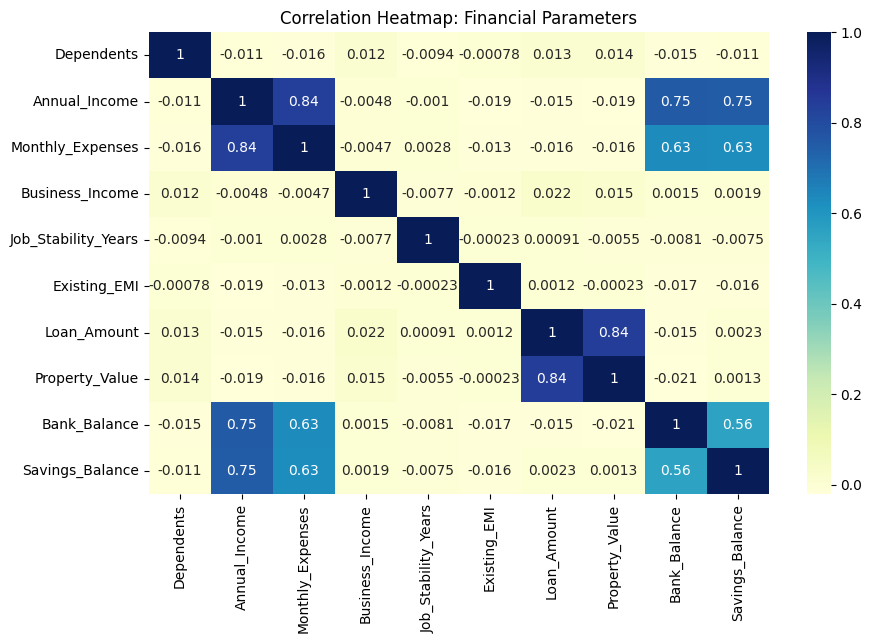

In [ ]:
# --- 1️⃣ Correlation Heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap: Financial Parameters")
plt.show()


In [ ]:
# ---------------- CREDIT SCORE ----------------
def auto_credit_score(u):
    inc = float(u.get("Annual_Income", 0))
    emi = float(u.get("Existing_EMI", 0))
    exp = float(u.get("Monthly_Expenses", 0)) * 12
    prop = float(u.get("Property_Value", 0))
    loan = float(u.get("Loan_Amount", 0))
    bank = float(u.get("Bank_Balance", 0))
    sav = float(u.get("Savings_Balance", 0))
    stab = float(u.get("Job_Stability_Years", 0))

    income_ratio = max((inc - (emi + exp)) / max(inc, 1), 0)
    liquidity = min((bank + sav) / max(inc, 1), 3)
    prop_ratio = min(prop / max(loan, 1), 10)
    stab_factor = min(stab / 10.0, 1.0)

    score = (0.45 * income_ratio) + (0.25 * min(prop_ratio/3.0, 1.0)) + \
            (0.15 * stab_factor) + (0.15 * min(liquidity/2.0, 1.0))
    return float(np.clip(score, 0.0, 1.0))

In [ ]:
# ---------------- SAFE LOAN (realistic weighting) ----------------
def recommended_safe_loan(u, credit):
    inc = float(u.get("Annual_Income", 0))
    emi = float(u.get("Existing_EMI", 0))
    exp = float(u.get("Monthly_Expenses", 0)) * 12
    prop = float(u.get("Property_Value", 0))
    avail = max(inc - (emi + exp), 0)
    base = avail * (4.0 + 2.0 * credit)
    prop_limit = prop * (0.3 + 0.1 * credit)
    recommended = 0.9 * (0.7 * base + 0.3 * prop_limit)
    return float(round(max(recommended, 50000.0), 2))

In [ ]:
# ---- Randomized Search for XGBoost ----
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.2],
    'reg_lambda': [0.5, 1.0, 1.5]
}
xgb_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("\n🔍 Running RandomizedSearchCV for XGBoost...")
xgb_search.fit(X_train_p, y_train)
xgb_clf_best = xgb_search.best_estimator_
print("✅ Best XGBoost Parameters:", xgb_search.best_params_)


🔍 Running RandomizedSearchCV for XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
✅ Best XGBoost Parameters: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.2, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [ ]:
# ---- Randomized Search for Random Forest ----
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}
rf_search = RandomizedSearchCV(
    estimator=rf_clf,
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("\n🔍 Running RandomizedSearchCV for Random Forest...")
rf_search.fit(X_train_p, y_train)
rf_clf_best = rf_search.best_estimator_
print("✅ Best RandomForest Parameters:", rf_search.best_params_)

# Logistic Regression stays same
lr_clf.fit(X_train_p, y_train)

# Use tuned models in ensemble
voting = VotingClassifier([("xgb", xgb_clf_best), ("rf", rf_clf_best), ("lr", lr_clf)], voting="soft", n_jobs=-1)
voting.fit(X_train_p, y_train)


🔍 Running RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
✅ Best RandomForest Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}


VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='mlogloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_co...
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=-1,
                                            num_class=3, ...)),
                             ('rf',
                              RandomForestClassifier(bootstrap=False,
                                                     class_weight='balanced_subsample',
                                                     min_samples_leaf=2,
                                                     min_samples_split=5,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('lr',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=1000,
                                                 solver='liblinear'))],
                 n_jobs=-1, voting='soft')

In [ ]:
# ---------------- PREDICT USER ----------------
def predict_user(u):
    # Convert input dict to DataFrame
    df_user = pd.DataFrame([u])
    for col in preproc.feature_names_in_:
        if col not in df_user.columns:
            df_user[col] = np.nan
    df_user = df_user[preproc.feature_names_in_]

    # Auto compute credit score
    credit = auto_credit_score(u)
    if "Credit_Score" in df_user.columns:
        df_user.loc[0, "Credit_Score"] = credit

    # Transform features
    Xp = preproc.transform(df_user)
    Xs = selector.transform(Xp)
    proba = voting.predict_proba(Xp)[0]

    # Extract key numeric inputs
    inc = float(u.get("Annual_Income", 0))
    emi = float(u.get("Existing_EMI", 0))
    exp = float(u.get("Monthly_Expenses", 0)) * 12
    prop = float(u.get("Property_Value", 0))
    loan_req = float(u.get("Loan_Amount", 0))

    # ✅ Compute financial ratios
    income_ratio = max((inc - (emi + exp)) / max(inc, 1), 0)
    prop_ratio = min(prop / max(loan_req, 1), 10)

    # ✅ Combined eligibility score (0–1)
    financial_score = np.clip(
        0.45 * credit + 0.25 * income_ratio + 0.30 * min(prop_ratio / 3.0, 1.0), 0, 1
    )

    # ✅ Recommended safe loan (initial)
    rec_loan = recommended_safe_loan(u, credit)

    # ✅ New proportional logic
    if financial_score >= 0.6 and loan_req <= rec_loan:
        category = "Fully Eligible"
        # Safe to approve requested loan
        rec_loan = loan_req
    elif 0.4 <= financial_score < 0.6:
        category = "Partially Eligible"
        # Suggest a proportional safe amount (e.g., 0.57 * requested loan)
        rec_loan = loan_req * financial_score
    else:
        category = "Not Eligible"
        # Suggest only half of proportional amount (more conservative)
        rec_loan = loan_req * financial_score * 0.5

    # ✅ Optional: Similarity-based context (for explainability)
    sims, sim_details = 0.0, []
    if approved_matrix.shape[0] > 0:
        s = cosine_similarity(Xs, approved_matrix)[0]
        s = np.clip((s - s.min()) / (np.ptp(s) + 1e-9), 0.0, 1.0)
        sims = float(np.mean(s[np.argsort(s)[-5:]]))

        # Include top 3 similar approved applicants
        top_idx = np.argsort(s)[-3:][::-1]
        approved_df = df[approved_mask].iloc[top_idx]
        for i, idx in enumerate(top_idx):
            sim_details.append({
                "rank": i + 1,
                "similarity": round(float(s[idx]), 3),
                "Annual_Income": approved_df.iloc[i]["Annual_Income"],
                "Loan_Amount": approved_df.iloc[i]["Loan_Amount"]
            })

    # ✅ Explanation / Reasons
    reasons = []
    if category == "Fully Eligible":
        reasons.append("Strong financial profile — safe for requested loan.")
    elif category == "Partially Eligible":
        reasons.append(
            f"Moderate eligibility — consider reducing your loan amount to about ₹{int(rec_loan):,}."
        )
    else:
        reasons.append(
            f"Low eligibility — current profile safely supports only around ₹{int(rec_loan):,}."
        )

    # ✅ Return results
    return {
        "credit_score": round(credit, 3),
        "eligibility_score": round(financial_score, 3),
        "category": category,
        "recommended_loan": rec_loan,
        "similarity": round(sims, 3),
        "similar_applicants": sim_details,
        "reasons": reasons
    }

In [ ]:
#  SMARTLOAN — Context-Aware SHAP Explainability

def model_predict(data):
    return xgb_clf.predict_proba(data)
explainer = shap.Explainer(model_predict, X_train_p, feature_names=preproc.feature_names_in_)


def explain_user_with_shap(u, category):
    df_user = pd.DataFrame([u])
    for col in preproc.feature_names_in_:
        if col not in df_user.columns:
            df_user[col] = np.nan
    df_user = df_user[preproc.feature_names_in_]
    Xp = preproc.transform(df_user)

    # Get SHAP values for this sample
    shap_values = explainer(Xp)
    if hasattr(shap_values, "values"):
        if shap_values.values.ndim == 3:
            shap_vals = shap_values.values[0][:, 2]  # For "Fully Eligible"
        else:
            shap_vals = shap_values.values[0]
    else:
        shap_vals = shap_values[0]

    shap_df = pd.DataFrame({
        "Feature": X.columns,
        "SHAP Value": shap_vals
    }).sort_values("SHAP Value", ascending=False)

    # Financially meaningful names
    feature_map = {
        "Annual_Income": "high annual income",
        "Property_Value": "valuable property assets",
        "Savings_Balance": "strong savings reserves",
        "Bank_Balance": "good liquidity",
        "Job_Stability_Years": "stable employment history",
        "Education_Level": "strong educational background",
        "Dependents": "manageable family dependents",
        "Existing_EMI": "existing EMI commitments",
        "Monthly_Expenses": "high monthly expenses",
        "Loan_Amount": "large loan request",
        "Business_Income": "business revenue",
        "Employment_Type": "job type and sector stability",
        "Age": "financial maturity"
    }

    top_positive = [feature_map.get(f, f) for f in shap_df.head(2)["Feature"].tolist()]
    top_negative = [feature_map.get(f, f) for f in shap_df.tail(2)["Feature"].tolist()]

    # Adaptive explanations
    if category == "Fully Eligible":
        reason_eligible = f"Fully eligible because of {', '.join(top_positive)}."
        reason_not = f"Minor risk factors include {', '.join(top_negative)}."
    elif category == "Partially Eligible":
        reason_eligible = f"Partially eligible mainly because of {', '.join(top_positive)}."
        reason_not = f"However, eligibility is affected by {', '.join(top_negative)}."
    else:  # Not Eligible
        reason_eligible = f"Not eligible due to {', '.join(top_negative)}."
        reason_not = f"Improving {', '.join(top_positive)} could increase eligibility."

    print("\n🔍 Explanation:")
    print(reason_eligible)
    print(reason_not)
    return reason_eligible + " " + reason_not

In [ ]:
 # ---------------- CLI ----------------
def run_cli():
    print("\n====== SMARTLOAN ELIGIBILITY CHECK ======\n")
    fields = [
        "Name","Age","Gender","Marital_Status","Dependents","Employment_Type","Education_Level",
        "Annual_Income","Monthly_Expenses","Business_Income","Job_Stability_Years","Existing_EMI",
        "Loan_Type","Loan_Amount","Property_Value","Document_Status","Bank_Balance","Savings_Balance"
    ]
    u = {}
    for f in fields:
        v = input(f"{f}: ").strip()
        if f in ["Age","Dependents","Annual_Income","Monthly_Expenses","Business_Income",
                 "Job_Stability_Years","Existing_EMI","Loan_Amount","Property_Value",
                 "Bank_Balance","Savings_Balance"]:
            try:
                u[f] = float(v) if v != "" else 0.0
            except:
                u[f] = 0.0
        else:
            u[f] = v if v != "" else ""

    print("\nAnalyzing your eligibility...\n")
    r = predict_user(u)

    print("-----------------------------------------------------")
    print("Applicant:", u.get("Name", "N/A"))
    print("Auto Credit Score (0–1):", r["credit_score"])
    print("Eligibility Score (0–1):", r["eligibility_score"])
    print("Category:", r["category"])
    print("Recommended Safe Loan (₹):", int(r["recommended_loan"]))
    print("Similarity Score:", r["similarity"])
    for s in r["similar_applicants"]:
        print(f" Rank {s['rank']} | Sim: {s['similarity']} | Income: ₹{int(s['Annual_Income'])} | Loan: ₹{int(s['Loan_Amount'])}")
    print("\nReasons:")
    for reason in r["reasons"]:
        print("-", reason)
    print("-----------------------------------------------------")

    explain_user_with_shap(u, r["category"]) # Pass the category


if __name__ == "__main__":
    t0 = time.time()
    run_cli()
    print("⏱ Runtime:", round(time.time()-t0, 1), "seconds")



====== SMARTLOAN ELIGIBILITY CHECK ======



In [ ]:
# ============================================================
# 📊 MODEL PERFORMANCE COMPARISON TABLE
# ============================================================

print("\n📊 MODEL PERFORMANCE COMPARISON TABLE\n")

models = {
    "Logistic Regression": lr_clf,
    "Random Forest": rf_clf,
    "XGBoost": xgb_clf,
    "SmartLoan (Ensemble)": voting
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_p)
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0) * 100
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0) * 100
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0) * 100
    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy (%)", "Precision (%)", "Recall (%)", "F1-Score (%)"])
print(results_df.to_string(index=False))


📊 MODEL PERFORMANCE COMPARISON TABLE

               Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
 Logistic Regression     98.785714      99.182692   98.785714     98.900547
       Random Forest     98.500000      98.613971   98.500000     98.548624
             XGBoost     99.357143      99.335158   99.357143     99.333005
SmartLoan (Ensemble)     99.142857      99.101336   99.142857     99.103618



📊 Generating Confusion Matrix for XGBoost (Fixed)...


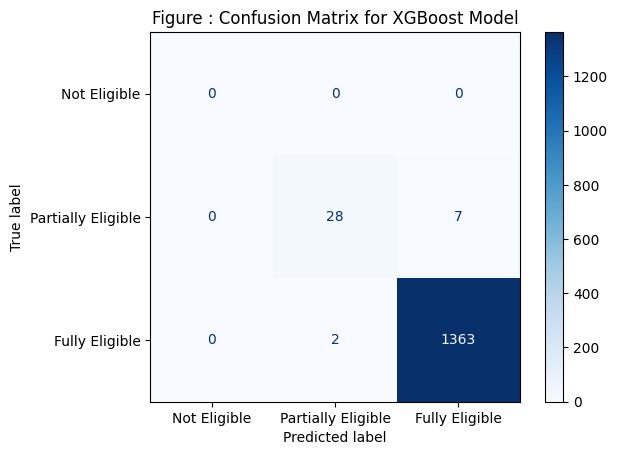


📊 Generating ROC Curves for All Models...


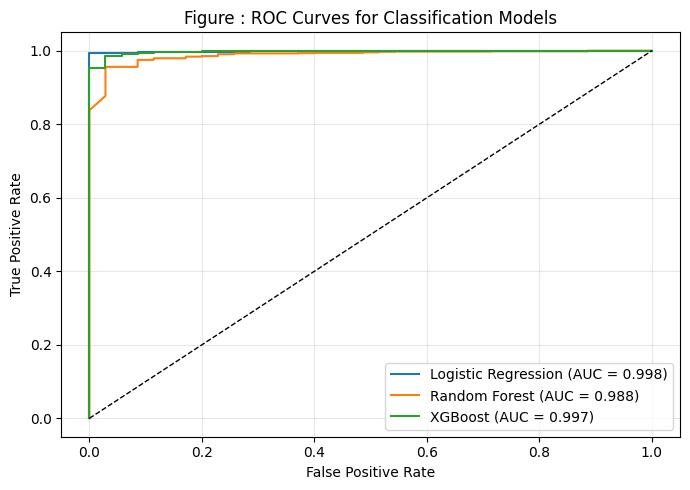


🎉 All visualizations generated successfully and saved as high-quality PNG files.


In [ ]:
# ============================================================
# 📊 SMARTLOAN — RESULTS VISUALIZATION (Figures 8.1 – 8.3)
# ============================================================

# 📊 FIGURE  — Confusion Matrix (XGBoost)
print("\n📊 Generating Confusion Matrix for XGBoost (Fixed)...")

labels = [0, 1, 2]
cm = confusion_matrix(y_test, xgb_clf.predict(X_test_p), labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Not Eligible", "Partially Eligible", "Fully Eligible"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Figure : Confusion Matrix for XGBoost Model", fontsize=12)
plt.show()

# 📊 FIGURE — ROC Curves (All Models)
print("\n📊 Generating ROC Curves for All Models...")

plt.figure(figsize=(7,5))
models = {
    "Logistic Regression": lr_clf,
    "Random Forest": rf_clf,
    "XGBoost": xgb_clf
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test_p)
    fpr, tpr, _ = roc_curve(y_test == 2, y_prob[:, 2])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.title("Figure : ROC Curves for Classification Models", fontsize=12)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🎉 All visualizations generated successfully and saved as high-quality PNG files.")


📊 Generating SHAP Summary Plot for XGBoost (Feature Names Visible)...


PermutationExplainer explainer: 1401it [12:40,  1.83it/s]


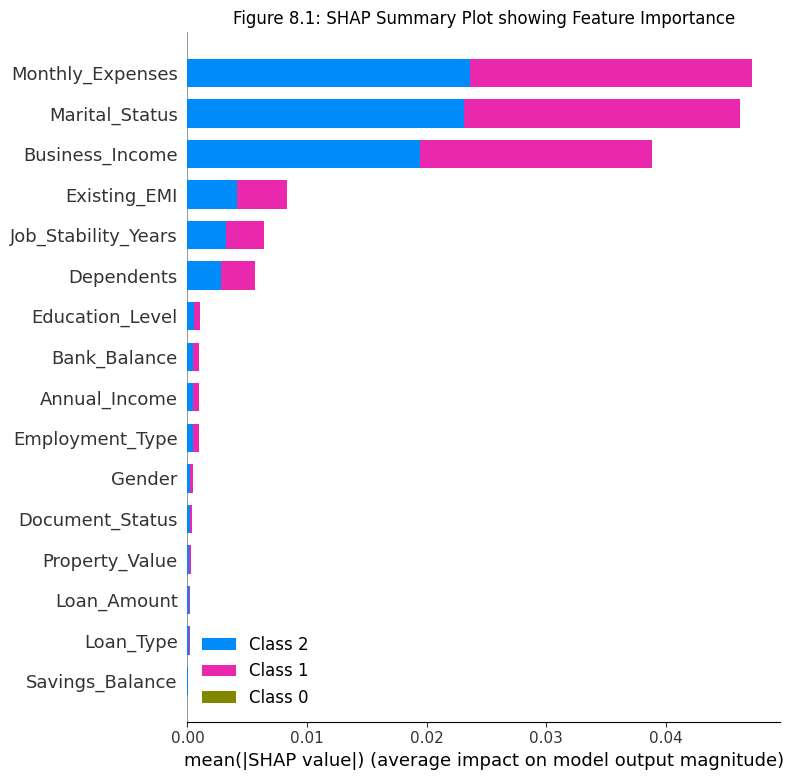

In [ ]:
# ======================================================
# 📊 FIGURE  — SHAP Feature Importance (with Feature Names)
# ======================================================

print("\n📊 Generating SHAP Summary Plot for XGBoost (Feature Names Visible)...")

# Define a callable model wrapper for SHAP
def model_predict(data):
    return xgb_clf.predict_proba(data)

# Initialize SHAP Explainer with feature names
explainer = shap.Explainer(model_predict, X_test_p, feature_names=X.columns)
shap_values = explainer(X_test_p)

# Plot SHAP feature importance as a bar chart
plt.title("Figure 8.1: SHAP Summary Plot showing Feature Importance", fontsize=12)
shap.summary_plot(shap_values, features=X_test, feature_names=X.columns, plot_type="bar", show=False)
plt.tight_layout()
plt.show()
